# **Day 29: Probability Calibration and Decision Thresholds**
*Module 5 - Classification*

When a model says "70% chance of rain", it should rain on about 70% of such days. That property is **calibration**. Calibrated probabilities are essential for risk maps, cost-based decisions, combining models, uncertainty reporting and area estimation. Many popular models (SVM, Random Forest, boosted trees, neural networks, Naive Bayes) are **not** calibrated out of the box.

> A model's probability should mean what it says: of all cases predicted at 70%, about 70% should be positive. Calibration fixes probabilities that are too confident or too timid. The decision threshold (often 0.5) can then be chosen for the real cost of errors.
>
> *Example:* For landslide warnings, missing a slide is worse than a false alarm, so we might act at a probability of 0.3 instead of 0.5.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay, calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score
rng = np.random.default_rng(29)

X, y = make_classification(n_samples=20000, n_features=20, n_informative=6, n_redundant=6, random_state=0)
X_tr, X_rest, y_tr, y_rest = train_test_split(X, y, train_size=0.5, random_state=0)
X_cal, X_te, y_cal, y_te = train_test_split(X_rest, y_rest, test_size=0.5, random_state=0)

## **1. Reliability Diagrams**
Bin the predicted probabilities; in each bin plot the **mean prediction** (x) against the **observed fraction of positives** (y). A perfectly calibrated model lies on the diagonal.

**Expected Calibration Error:** $\text{ECE} = \sum_b \frac{n_b}{N}\lvert\bar y_b - \bar p_b\rvert$.

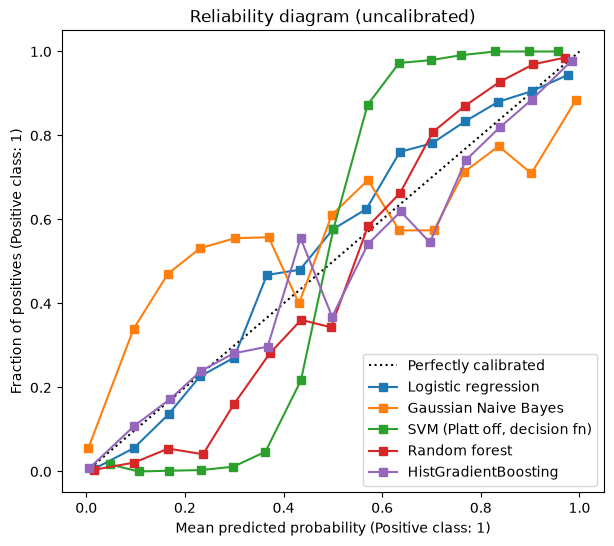

,ECE,Brier,ROC_AUC
model,,,
Logistic regression,0.0312,0.0792,0.9501
Gaussian Naive Bayes,0.0955,0.1150,0.9293
"SVM (Platt off, decision fn)",0.2441,0.1037,0.9853
Random forest,0.0410,0.0433,0.9839
HistGradientBoosting,0.0086,0.0368,0.9853


In [2]:
def ece(y_true, p, n_bins=15):
    bins = np.linspace(0, 1, n_bins + 1); idx = np.clip(np.digitize(p, bins) - 1, 0, n_bins - 1)
    return sum(np.sum(idx == b) / len(p) * abs(y_true[idx == b].mean() - p[idx == b].mean()) for b in range(n_bins) if np.any(idx == b))

models = {"Logistic regression": LogisticRegression(max_iter=1000), "Gaussian Naive Bayes": GaussianNB(),
          "SVM (Platt off, decision fn)": SVC(kernel="rbf", C=1.0), "Random forest": RandomForestClassifier(300, n_jobs=-1, random_state=0),
          "HistGradientBoosting": HistGradientBoostingClassifier(random_state=0)}
fig, ax = plt.subplots(figsize=(7, 6))
rows = []
for name, m in models.items():
    m.fit(X_tr, y_tr)
    if hasattr(m, "predict_proba"):
        p = m.predict_proba(X_te)[:, 1]
    else:                                                   # SVM: squash the decision function with min-max (NOT a probability)
        d = m.decision_function(X_te); p = (d - d.min()) / (d.max() - d.min())
    CalibrationDisplay.from_predictions(y_te, p, n_bins=15, name=name, ax=ax)
    rows.append({"model": name, "ECE": ece(y_te, p), "Brier": brier_score_loss(y_te, p), "ROC_AUC": roc_auc_score(y_te, p)})
ax.set_title("Reliability diagram (uncalibrated)"); plt.show()
pd.DataFrame(rows).set_index("model").round(4)

**Typical patterns** (Niculescu-Mizil & Caruana, 2005):
- **Naive Bayes**: pushes probabilities to 0 and 1 (overconfident) because it double-counts correlated features.
- **Random Forest**: S-shaped, under-confident at the extremes (averaging trees rarely gives exactly 0 or 1).
- **SVM**: produces margins, not probabilities.
- **Logistic regression**: usually well calibrated (it directly optimises log loss).

Notice that **ROC-AUC is unaffected** by calibration: calibration changes the probability scale, not the ranking.

## **2. Calibration Methods**

| Method | Maps score $s$ to | Pros / cons |
|---|---|---|
| **Platt / sigmoid** | $\sigma(as + b)$ | 2 parameters, needs little data; assumes a sigmoid shape |
| **Isotonic regression** | any monotone step function | Flexible; needs more data (> ~1000), can overfit |
| **Temperature scaling** | softmax$(z/T)$ | 1 parameter; standard for neural networks |

Calibration must be fitted on data **not used to train the model** (a calibration set or cross-validation).

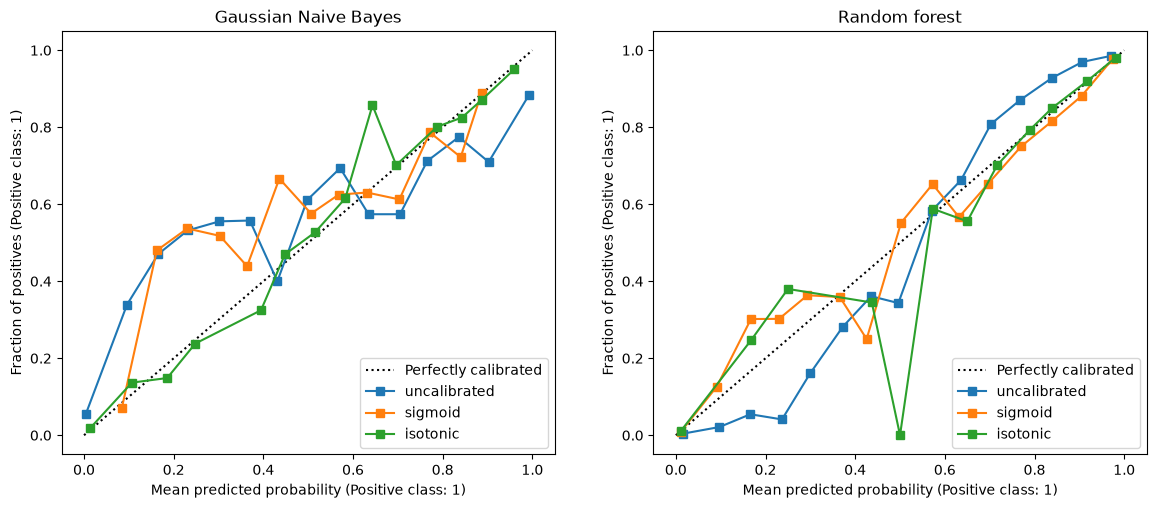

,model,method,ECE,Brier,log_loss
0,Gaussian Naive Bayes,uncalibrated,0.0955,0.1150,0.5559
1,Gaussian Naive Bayes,sigmoid,0.0311,0.1097,0.3658
2,Gaussian Naive Bayes,isotonic,0.0138,0.1005,0.3818
3,Random forest,uncalibrated,0.0410,0.0433,0.1696
4,Random forest,sigmoid,0.0094,0.0402,0.1470
5,Random forest,isotonic,0.0059,0.0404,0.1599


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
rows = []
for ax, base_name in zip(axes, ["Gaussian Naive Bayes", "Random forest"]):
    base = models[base_name]
    for method in [None, "sigmoid", "isotonic"]:
        if method is None:
            p = base.predict_proba(X_te)[:, 1]; label = "uncalibrated"
        else:
            from sklearn.frozen import FrozenEstimator
            cal = CalibratedClassifierCV(FrozenEstimator(base), method=method).fit(X_cal, y_cal)   # base already trained: calibrate on X_cal
            p = cal.predict_proba(X_te)[:, 1]; label = method
        CalibrationDisplay.from_predictions(y_te, p, n_bins=15, name=label, ax=ax)
        rows.append({"model": base_name, "method": label, "ECE": ece(y_te, p), "Brier": brier_score_loss(y_te, p), "log_loss": log_loss(y_te, p)})
    ax.set_title(base_name)
plt.show()
pd.DataFrame(rows).round(4)

`FrozenEstimator` tells scikit-learn the base model is already fitted, so only the calibrator is trained on `X_cal`. Alternatively, `CalibratedClassifierCV(model, cv=5)` fits models and calibrators with internal cross-validation on the training data.

## **3. Temperature Scaling (Multi-Class)**
Divide the logits by a single temperature $T$ chosen to minimise log loss on a validation set. $T > 1$ softens overconfident predictions. It never changes the predicted class.

In [4]:
from scipy.optimize import minimize_scalar
from scipy.special import softmax, log_softmax
Xm, ym = make_classification(9000, 20, n_informative=10, n_classes=4, n_clusters_per_class=1, random_state=1)
Xm_tr, Xm_val, Xm_te = Xm[:5000], Xm[5000:7000], Xm[7000:]
ym_tr, ym_val, ym_te = ym[:5000], ym[5000:7000], ym[7000:]
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(2, include_bias=False).fit(Xm_tr)
lr_over = LogisticRegression(C=1e4, max_iter=20000).fit(poly.transform(Xm_tr[:400]), ym_tr[:400])   # 230 features, 400 samples: overfits
logits_val = lr_over.decision_function(poly.transform(Xm_val)); logits_te = lr_over.decision_function(poly.transform(Xm_te))
nll = lambda T: -np.mean(log_softmax(logits_val / T, axis=1)[np.arange(len(ym_val)), ym_val])
T = minimize_scalar(nll, bounds=(0.05, 20), method="bounded").x
for name, Tv in [("before (T=1)", 1.0), (f"after (T={T:.2f})", T)]:
    P = softmax(logits_te / Tv, axis=1)
    print(f"{name:<16} log loss {log_loss(ym_te, P):.4f} | accuracy {np.mean(P.argmax(1) == ym_te):.4f} | mean max-prob {P.max(1).mean():.3f}")

before (T=1)     log loss 1.6373 | accuracy 0.8655 | mean max-prob 0.982
after (T=9.49)   log loss 0.4276 | accuracy 0.8655 | mean max-prob 0.827


## **4. Choosing the Decision Threshold**
Calibrated probabilities + a decision rule. Three common rules:
1. **Maximise a metric** (F1, MCC, Youden's J) on validation data.
2. **Minimise expected cost**: positive if $p > \frac{C_{FP}}{C_{FP}+C_{FN}}$.
3. **Meet a constraint**: e.g. recall >= 95% (screening), or precision >= 90% (alerts).

In [5]:
from sklearn.model_selection import TunedThresholdClassifierCV, FixedThresholdClassifier
from sklearn.metrics import make_scorer, f1_score, recall_score, precision_score

Xi, yi = make_classification(10000, 15, n_informative=5, weights=[0.9], random_state=3)
Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(Xi, yi, test_size=0.4, stratify=yi, random_state=0)
base = HistGradientBoostingClassifier(random_state=0)

def cost_score(y_true, y_pred, c_fp=1, c_fn=10):
    return -(c_fp * np.sum((y_pred == 1) & (y_true == 0)) + c_fn * np.sum((y_pred == 0) & (y_true == 1)))

rules = {"default 0.5": FixedThresholdClassifier(base, threshold=0.5),
         "max F1": TunedThresholdClassifierCV(base, scoring="f1", cv=5),
         "min cost (FN = 10 x FP)": TunedThresholdClassifierCV(base, scoring=make_scorer(cost_score), cv=5)}
rows = []
for name, r in rules.items():
    r.fit(Xi_tr, yi_tr); pred = r.predict(Xi_te)
    thr = r.threshold if hasattr(r, "threshold") else r.best_threshold_
    rows.append({"rule": name, "threshold": thr, "precision": precision_score(yi_te, pred), "recall": recall_score(yi_te, pred),
                 "F1": f1_score(yi_te, pred), "cost": -cost_score(yi_te, pred)})
pd.DataFrame(rows).set_index("rule").round(3)

,threshold,precision,recall,F1,cost
rule,,,,,
default 0.5,0.500,0.882,0.721,0.794,1200
max F1,0.252,0.824,0.798,0.811,911
min cost (FN = 10 x FP),0.050,0.615,0.904,0.732,635


# **Part 2: Going Deeper**

### Brier score decomposition (Murphy, 1973)
$\text{Brier} = \underbrace{\text{reliability}}_{\text{calibration error (lower better)}} - \underbrace{\text{resolution}}_{\text{discrimination (higher better)}} + \underbrace{\text{uncertainty}}_{\bar y(1-\bar y)}$

In [6]:
def brier_decomposition(y_true, p, n_bins=10):
    bins = np.clip((p * n_bins).astype(int), 0, n_bins - 1); ybar = y_true.mean(); rel = res = 0.0
    for b in range(n_bins):
        m = bins == b
        if m.any():
            rel += m.sum() * (p[m].mean() - y_true[m].mean()) ** 2; res += m.sum() * (y_true[m].mean() - ybar) ** 2
    return {"reliability": rel / len(p), "resolution": res / len(p), "uncertainty": ybar * (1 - ybar), "Brier": brier_score_loss(y_true, p)}
p_nb = models["Gaussian Naive Bayes"].predict_proba(X_te)[:, 1]
from sklearn.frozen import FrozenEstimator
p_nb_cal = CalibratedClassifierCV(FrozenEstimator(models["Gaussian Naive Bayes"]), method="isotonic").fit(X_cal, y_cal).predict_proba(X_te)[:, 1]
pd.DataFrame({"NB raw": brier_decomposition(y_te, p_nb), "NB isotonic": brier_decomposition(y_te, p_nb_cal)}).round(4)

,NB raw,NB isotonic
reliability,0.0115,0.0003
resolution,0.1447,0.1492
uncertainty,0.2500,0.2500
Brier,0.1150,0.1005


Calibration reduces the **reliability** term; resolution (the model's ability to separate classes) barely changes.

### Calibration breaks under dataset shift
A model calibrated in one region, season or hospital is often miscalibrated elsewhere (Ovadia et al., 2019). The simplest case is **prior shift**: the class is much rarer in the new area than in the training data (here 50% -> ~13%). The model's probabilities are still ~50% on average, so they are far too high. Recalibrate with a small labelled sample from the new domain (Day 79), or apply the prior-shift correction from Day 21.

In [7]:
keep = (y_te == 0) | (rng.random(len(y_te)) < 0.15)            # keep all negatives, 15% of positives
X_new, y_new = X_te[keep], y_te[keep]
p_new = models["Logistic regression"].predict_proba(X_new)[:, 1]
print(f"Positive rate: training-like test set {y_te.mean():.2f} | new area {y_new.mean():.2f}")
print(f"Logistic regression ECE: in-domain {ece(y_te, models['Logistic regression'].predict_proba(X_te)[:, 1]):.4f} | new area {ece(y_new, p_new):.4f}")
recal = LogisticRegression().fit(np.log(p_new[:300] / (1 - p_new[:300]))[:, None], y_new[:300])     # recalibrate on 300 labelled samples
p_recal = recal.predict_proba(np.log(p_new[300:] / (1 - p_new[300:]))[:, None])[:, 1]
print(f"After recalibration on 300 new-area samples: ECE {ece(y_new[300:], p_recal):.4f}")

Positive rate: training-like test set 0.50 | new area 0.13
Logistic regression ECE: in-domain 0.0312 | new area 0.1186
After recalibration on 300 new-area samples: ECE 0.0322


## **Practice Problems**
1. Calibrate the SVM with `CalibratedClassifierCV(SVC(), method="sigmoid", cv=5)` and plot its reliability diagram.
2. Show that isotonic calibration on a **tiny** calibration set (200 samples) can be worse than sigmoid.
3. For the cost rule with $C_{FN}=10C_{FP}$, what is the theoretical threshold for calibrated probabilities? Compare with the tuned one.
4. *(Advanced)* Implement Platt scaling ourselves: fit `LogisticRegression` on the RF's calibration-set probabilities (as a single feature) and compare with `method="sigmoid"`.

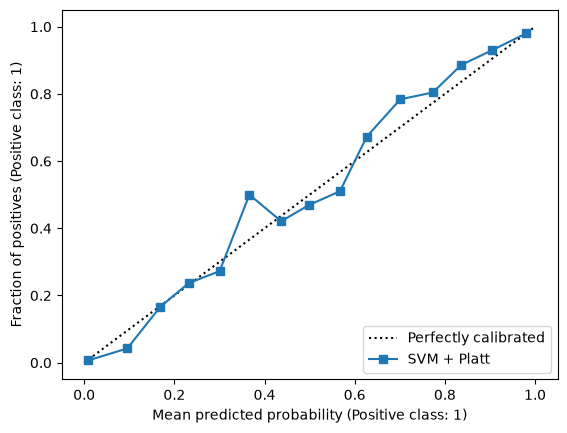

sigmoid   with 200 calibration samples: Brier 0.0490


isotonic  with 200 calibration samples: Brier 0.0519
Theoretical threshold: 0.091 | tuned: 0.05 -> close; the gap comes from imperfect calibration and sampling noise in the CV folds


my Platt Brier 0.0401 | sklearn sigmoid Brier 0.0402


In [8]:
# Solution 1
svm_cal = CalibratedClassifierCV(SVC(), method="sigmoid", cv=5).fit(X_tr[:4000], y_tr[:4000])
CalibrationDisplay.from_estimator(svm_cal, X_te, y_te, n_bins=15, name="SVM + Platt"); plt.show()
# Solution 2
for method in ["sigmoid", "isotonic"]:
    c = CalibratedClassifierCV(FrozenEstimator(models["Random forest"]), method=method).fit(X_cal[:200], y_cal[:200])
    print(f"{method:<9} with 200 calibration samples: Brier {brier_score_loss(y_te, c.predict_proba(X_te)[:, 1]):.4f}")
# Solution 3
print("Theoretical threshold:", round(1 / 11, 3), "| tuned:", round(rules["min cost (FN = 10 x FP)"].best_threshold_, 3),
      "-> close; the gap comes from imperfect calibration and sampling noise in the CV folds")
# Solution 4
s_cal = models["Random forest"].predict_proba(X_cal)[:, [1]]
platt = LogisticRegression().fit(s_cal, y_cal)
p_platt = platt.predict_proba(models["Random forest"].predict_proba(X_te)[:, [1]])[:, 1]
p_sk = CalibratedClassifierCV(FrozenEstimator(models["Random forest"]), method="sigmoid").fit(X_cal, y_cal).predict_proba(X_te)[:, 1]
print(f"my Platt Brier {brier_score_loss(y_te, p_platt):.4f} | sklearn sigmoid Brier {brier_score_loss(y_te, p_sk):.4f}")

## **Key References**
- Platt, J. (1999). Probabilistic outputs for support vector machines and comparisons to regularized likelihood methods. *Advances in Large Margin Classifiers*, 61-74.
- Zadrozny, B., & Elkan, C. (2002). Transforming classifier scores into accurate multiclass probability estimates. *KDD 2002*, 694-699.
- Niculescu-Mizil, A., & Caruana, R. (2005). Predicting good probabilities with supervised learning. *ICML 2005*, 625-632.
- Guo, C., Pleiss, G., Sun, Y., & Weinberger, K. Q. (2017). On calibration of modern neural networks. *ICML 2017*.
- Murphy, A. H. (1973). A new vector partition of the probability score. *Journal of Applied Meteorology*, 12(4), 595-600.
- Ovadia, Y. et al. (2019). Can you trust your model's uncertainty? Evaluating predictive uncertainty under dataset shift. *NeurIPS 2019*.